# EDA — espaces_verts.csv
Score de Vivabilité · Inventaire des espaces verts parisiens

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import csv

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130

## 1. Chargement

> ⚠️ Ce fichier contient des champs GeoJSON volumineux. On utilise `quoting=csv.QUOTE_NONE` pour contourner la limite de taille pandas.

In [2]:
from pathlib import Path

BASE_DIR = Path.cwd().parents[0]
FILE = BASE_DIR / 'brute' / 'score_de_vivabilité' / 'espaces_verts.csv'

df = pd.read_csv(
    FILE,
    sep=None,
    engine='python',
    on_bad_lines='skip',
    quoting=csv.QUOTE_NONE,
    escapechar='\\'
)
df.columns = df.columns.str.strip().str.replace('\ufeff', '', regex=False)
print(f'Shape : {df.shape}')
print(f'Colonnes : {list(df.columns)}')
df.head()

Shape : (983, 27)
Colonnes : ['ID', 'NSQ_EV', 'NOM', 'TYPE ESPACES VERTS FRAIS', 'PART VEGETATION HAUTE', 'PROPORTION VEGETATION HAUTE', 'ADRESSE', 'ARRONDISSEMENT', 'STATUT OUVERTURE', 'OUVERTURE 24-24H', 'OUVERTURE PERIODE CANICULE', 'OUVERTURE ESTIVALE NOCTURNE', 'HORAIRES PERIODE', 'HORAIRES LUNDI', 'HORAIRES MARDI', 'HORAIRES MERCREDI', 'HORAIRES JEUDI', 'HORAIRES VENDREDI', 'HORAIRES SAMEDI', 'HORAIRES DIMANCHE', 'Catégorie Espace Vert', 'Bon plan proposé par un usager (O/N)', 'Identifiant DICOM', 'geo_shape', 'geo_point_2d', 'Surface végétation supérieure 8m 2024', 'Indice végétation supérieure 8m 2024']


,ID,NSQ_EV,NOM,TYPE ESPACES VERTS FRAIS,PART VEGETATION HAUTE,PROPORTION VEGETATION HAUTE,ADRESSE,ARRONDISSEMENT,STATUT OUVERTURE,OUVERTURE 24-24H,...,HORAIRES VENDREDI,HORAIRES SAMEDI,HORAIRES DIMANCHE,Catégorie Espace Vert,Bon plan proposé par un usager (O/N),Identifiant DICOM,geo_shape,geo_point_2d,Surface végétation supérieure 8m 2024,Indice végétation supérieure 8m 2024
0,ID1598,12950.0,JARDINIERES DU BOULEVARD BOURDON,Décorations sur la voie publique,0.400000,40.000000,2 BOULEVARD BOURDON,75004.0,NaN,Oui,...,NaN,NaN,NaN,Jardiniere,NaN,NaN,"""{""""coordinates"""": [[[[2.3678529863576805, 48....","48.84947745578647, 2.366824061471092",624.205223,0.400000
1,ID827,NaN,Jardin de la place Mohamed Bouazizi,Promenades ouvertes,0.700000,70.000000,place Mohamed Bouazizi,75014.0,NaN,Oui,...,NaN,NaN,NaN,NaN,NaN,NaN,"""{""""coordinates"""": [[[2.3372394089128443, 48.8...","48.82492124484592, 2.3375972684224844",120.179045,0.700000
2,ID681,147.0,MAIL PIERRE DESPROGES DIT TROTTOIR PIERRE DESP...,Promenades ouvertes,0.685502,68.550155,143 RUE DE LA ROQUETTE,75011.0,NaN,Oui,...,NaN,NaN,NaN,Mail,NaN,NaN,"""{""""coordinates"""": [[[[2.3843589417286357, 48....","48.85908606441403, 2.385181940282387",522.406493,0.408195
3,ID733,664.0,MAIL MARCEL ACHARD,Promenades ouvertes,0.382438,38.243819,6 PL MARCEL ACHARD,75019.0,NaN,Non,...,NaN,NaN,NaN,Mail,NaN,NaN,"""{""""coordinates"""": [[[2.376518530160643, 48.87...","48.873382427669476, 2.3766848518891344",1914.907047,0.444426
4,ID1211,10045.0,Bois de Boulogne,Bois,0.822828,82.282848,NaN,75016.0,NaN,Non,...,00h00 - 23h59,00h00 - 23h59,00h00 - 23h59,Bois,NaN,2779,"""{""""coordinates"""": [[[[2.2710475849599234, 48....","48.87171620646602, 2.268302862988442",153846.532000,0.630035


## 2. Infos générales

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 983 entries, 0 to 982
Data columns (total 27 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   ID                                     959 non-null    str    
 1   NSQ_EV                                 951 non-null    float64
 2   NOM                                    982 non-null    str    
 3   TYPE ESPACES VERTS FRAIS               981 non-null    str    
 4   PART VEGETATION HAUTE                  953 non-null    float64
 5   PROPORTION VEGETATION HAUTE            953 non-null    float64
 6   ADRESSE                                815 non-null    str    
 7   ARRONDISSEMENT                         982 non-null    float64
 8   STATUT OUVERTURE                       6 non-null      str    
 9   OUVERTURE 24-24H                       969 non-null    str    
 10  OUVERTURE PERIODE CANICULE             972 non-null    str    
 11  OUVERTURE ESTIVAL

In [4]:
df.describe(include='all')

,ID,NSQ_EV,NOM,TYPE ESPACES VERTS FRAIS,PART VEGETATION HAUTE,PROPORTION VEGETATION HAUTE,ADRESSE,ARRONDISSEMENT,STATUT OUVERTURE,OUVERTURE 24-24H,...,HORAIRES VENDREDI,HORAIRES SAMEDI,HORAIRES DIMANCHE,Catégorie Espace Vert,Bon plan proposé par un usager (O/N),Identifiant DICOM,geo_shape,geo_point_2d,Surface végétation supérieure 8m 2024,Indice végétation supérieure 8m 2024
count,959,951.000000,982,981,953.000000,953.000000,815,982.000000,6,969,...,715,716,716,950,42,727,983,983,918.000000,982.000000
unique,953,NaN,826,10,NaN,NaN,753,NaN,1,2,...,40,41,38,22,2,510,980,980,NaN,NaN
top,ID1598,NaN,Bois de Vincennes,Promenades ouvertes,NaN,NaN,10 AV FOCH,NaN,Ouvert,Non,...,00h00 - 23h59,00h00 - 23h59,00h00 - 23h59,Square,Non,6598,"""{""""coordinates"""": [[[[2.3287257037132494, 48....","48.84574604135506, 2.3284964277605384",NaN,NaN
freq,2,NaN,103,606,NaN,NaN,24,NaN,6,782,...,291,291,291,276,40,103,2,2,NaN,NaN
mean,NaN,5763.883281,NaN,NaN,0.353362,35.336192,NaN,75072.570265,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9442.254747,0.339470
std,NaN,5182.447105,NaN,NaN,0.248967,24.896690,NaN,1064.920539,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27674.440890,0.252872
min,NaN,1.000000,NaN,NaN,0.000000,0.000000,NaN,75001.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
25%,NaN,349.500000,NaN,NaN,0.136307,13.630687,NaN,75012.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,275.759581,0.109207
50%,NaN,10045.000000,NaN,NaN,0.336527,33.652749,NaN,75014.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1009.321097,0.319765
75%,NaN,10132.000000,NaN,NaN,0.526331,52.633089,NaN,75016.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4307.307539,0.536181


## 3. Valeurs manquantes — critique pour ce dataset

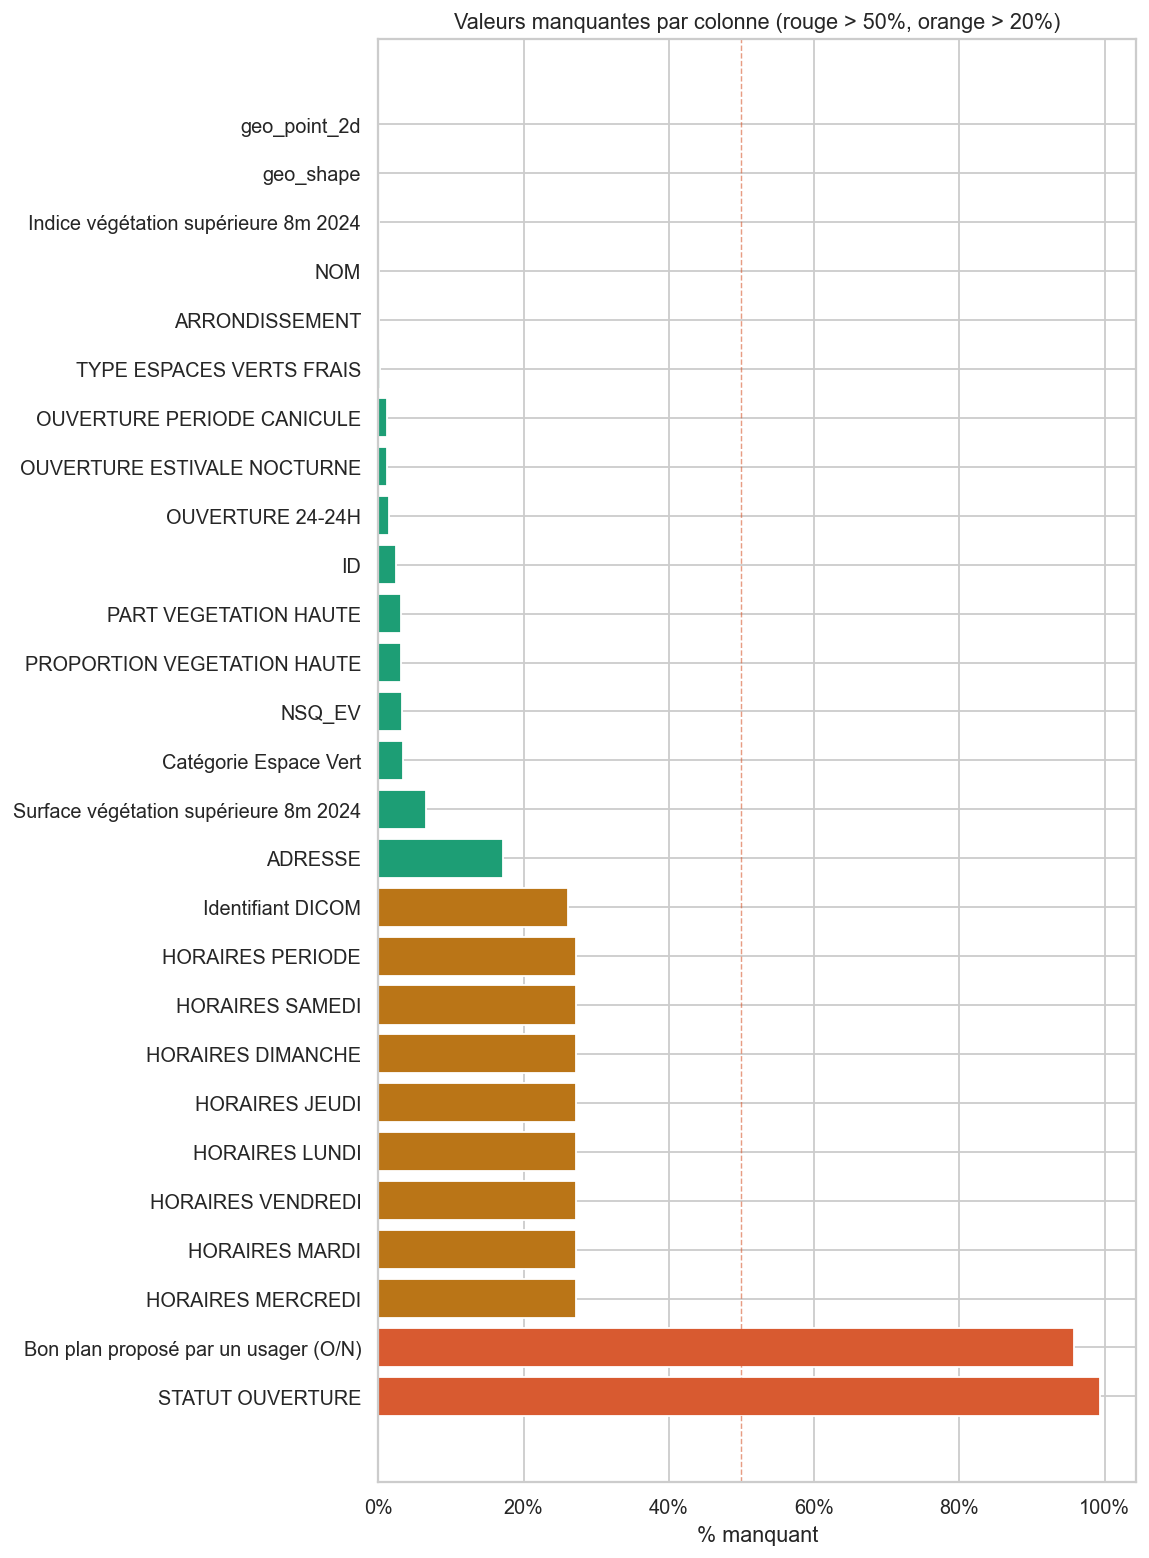

,% manquant
STATUT OUVERTURE,99.389624
Bon plan proposé par un usager (O/N),95.727365
HORAIRES MERCREDI,27.263479
HORAIRES MARDI,27.263479
HORAIRES VENDREDI,27.263479
HORAIRES LUNDI,27.263479
HORAIRES JEUDI,27.263479
HORAIRES DIMANCHE,27.161750
HORAIRES SAMEDI,27.161750
HORAIRES PERIODE,27.161750


In [5]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, max(3, len(df.columns) * 0.45)))
colors = ['#D85A30' if v > 50 else '#BA7517' if v > 20 else '#1D9E75' for v in missing.values]
ax.barh(missing.index, missing.values, color=colors)
ax.set_xlabel('% manquant')
ax.set_title('Valeurs manquantes par colonne (rouge > 50%, orange > 20%)')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.axvline(50, color='#D85A30', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

display(missing.rename('% manquant').to_frame())

## 4. Doublons

In [6]:
n_dup = df.duplicated().sum()
print(f'Doublons : {n_dup} ({n_dup/len(df)*100:.2f}%)')
if n_dup > 0:
    display(df[df.duplicated(keep=False)].head(10))

Doublons : 0 (0.00%)


## 5. Détection colonnes clés

In [7]:
def find_col(df, *keywords):
    for kw in keywords:
        match = [c for c in df.columns if kw.lower() in c.lower()]
        if match: return match[0]
    return None

col_map = {
    'nom'           : find_col(df, 'nom', 'name', 'libelle'),
    'type'          : find_col(df, 'type', 'categorie', 'nature', 'typsite'),
    'surface'       : find_col(df, 'surface', 'superficie', 'area'),
    'arrondissement': find_col(df, 'arrond', 'arrdt', 'arr'),
    'adresse'       : find_col(df, 'adresse', 'address', 'rue'),
    'geo_point'     : find_col(df, 'geo_point', 'geopoint', 'coord'),
    'geo_shape'     : find_col(df, 'geo_shape', 'geometry', 'geom'),
}

print('Colonnes détectées :')
for k, v in col_map.items():
    status = '✅' if v else '❌'
    print(f'  {status}  {k:20s} → {v}')
print(f'\nColonnes non mappées : {[c for c in df.columns if c not in col_map.values()]}')

Colonnes détectées :
  ✅  nom                  → NOM
  ✅  type                 → TYPE ESPACES VERTS FRAIS
  ✅  surface              → Surface végétation supérieure 8m 2024
  ✅  arrondissement       → ARRONDISSEMENT
  ✅  adresse              → ADRESSE
  ✅  geo_point            → geo_point_2d
  ✅  geo_shape            → geo_shape

Colonnes non mappées : ['ID', 'NSQ_EV', 'PART VEGETATION HAUTE', 'PROPORTION VEGETATION HAUTE', 'STATUT OUVERTURE', 'OUVERTURE 24-24H', 'OUVERTURE PERIODE CANICULE', 'OUVERTURE ESTIVALE NOCTURNE', 'HORAIRES PERIODE', 'HORAIRES LUNDI', 'HORAIRES MARDI', 'HORAIRES MERCREDI', 'HORAIRES JEUDI', 'HORAIRES VENDREDI', 'HORAIRES SAMEDI', 'HORAIRES DIMANCHE', 'Catégorie Espace Vert', 'Bon plan proposé par un usager (O/N)', 'Identifiant DICOM', 'Indice végétation supérieure 8m 2024']


## 6. Répartition par type d'espace vert

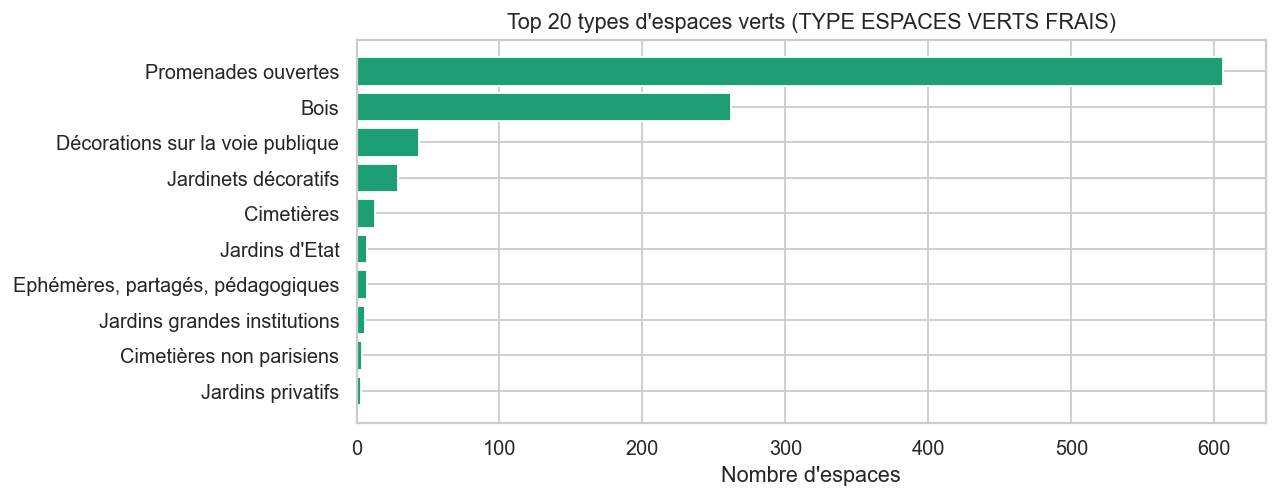

In [8]:
type_col = col_map['type']
if type_col:
    vc = df[type_col].value_counts().head(20)
    fig, ax = plt.subplots(figsize=(10, max(4, len(vc) * 0.4)))
    ax.barh(vc.index.astype(str), vc.values, color='#1D9E75')
    ax.set_title(f"Top 20 types d'espaces verts ({type_col})")
    ax.set_xlabel("Nombre d'espaces")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print('❌ Colonne type non trouvée — vérifier df.columns')

## 7. Répartition par arrondissement

Complétude arrondissement : 982/983 (99.9%)


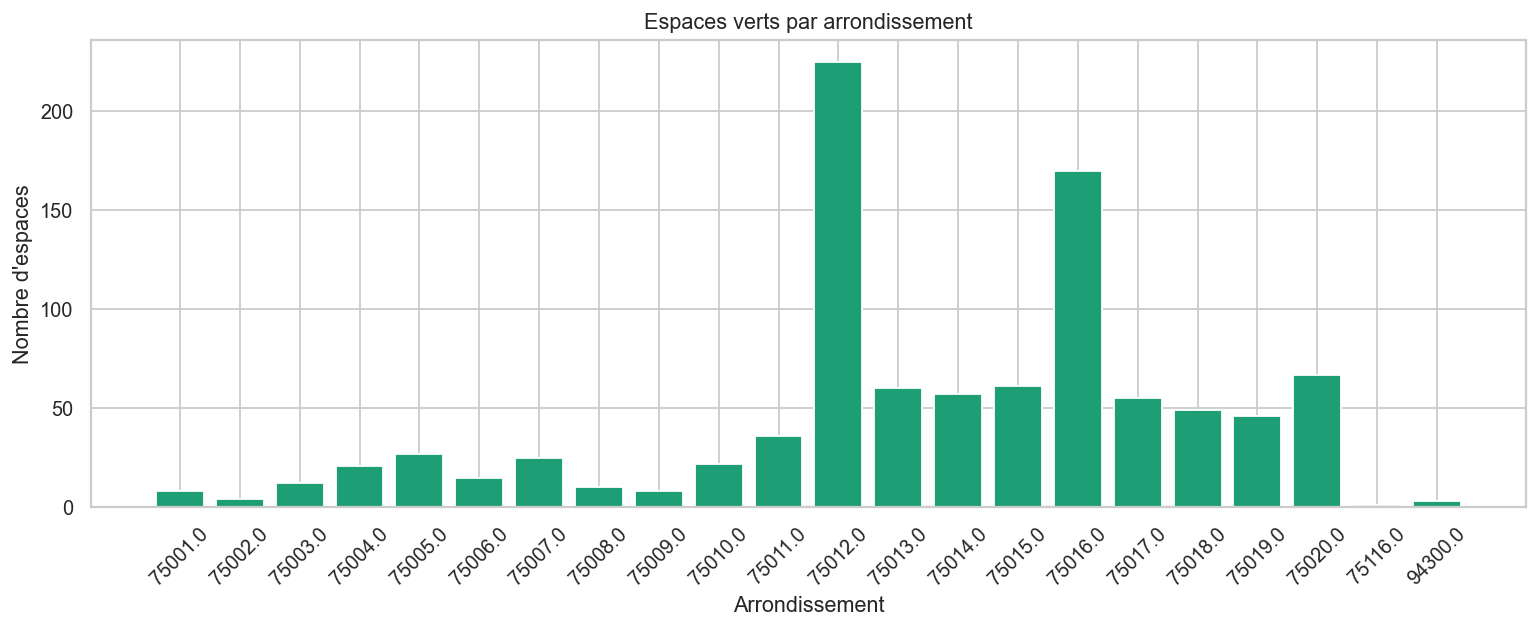

In [9]:
arr_col = col_map['arrondissement']
if arr_col:
    print(f'Complétude arrondissement : {df[arr_col].notna().sum()}/{len(df)} ({df[arr_col].notna().mean()*100:.1f}%)')
    vc_arr = df[arr_col].value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(vc_arr.index.astype(str), vc_arr.values, color='#1D9E75')
    ax.set_title("Espaces verts par arrondissement")
    ax.set_xlabel('Arrondissement')
    ax.set_ylabel("Nombre d'espaces")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('❌ Colonne arrondissement non trouvée')

## 8. Distribution des surfaces

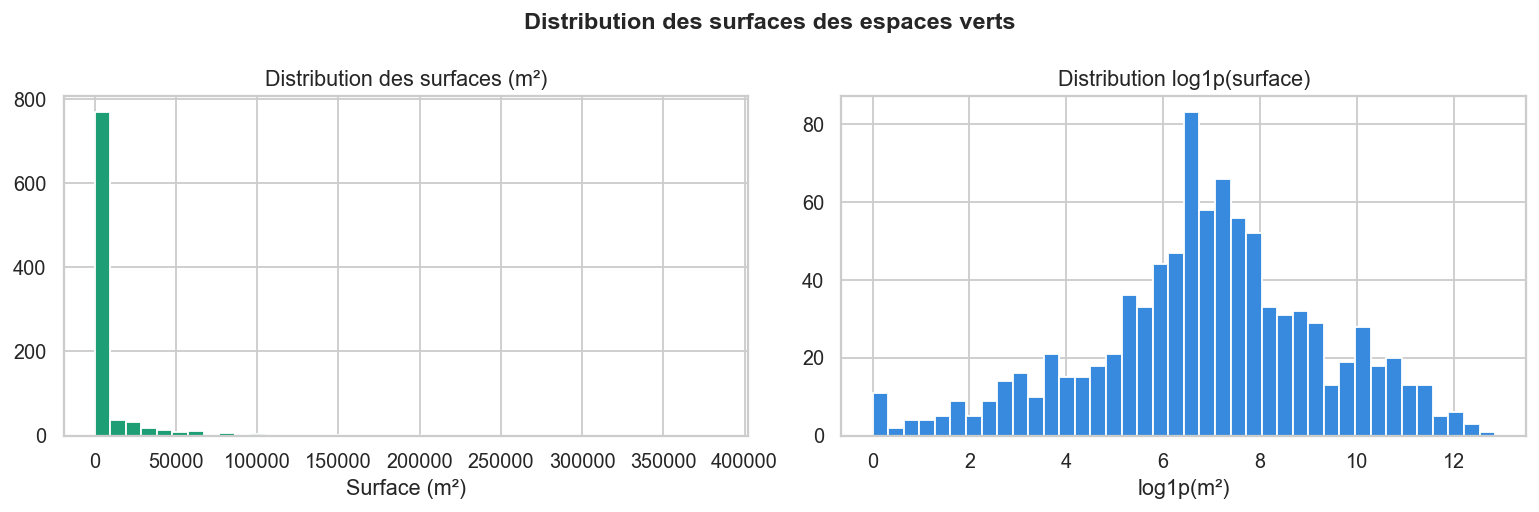

count       918.000000
mean       9442.254747
std       27674.440890
min           0.000000
25%         275.759581
50%        1009.321097
75%        4307.307539
max      383080.893000
Name: Surface végétation supérieure 8m 2024, dtype: float64


In [10]:
surf_col = col_map['surface']
if surf_col:
    df[surf_col] = pd.to_numeric(df[surf_col], errors='coerce')
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(df[surf_col].dropna(), bins=40, color='#1D9E75', edgecolor='white')
    axes[0].set_title('Distribution des surfaces (m²)')
    axes[0].set_xlabel('Surface (m²)')

    axes[1].hist(np.log1p(df[surf_col].dropna()), bins=40, color='#378ADD', edgecolor='white')
    axes[1].set_title('Distribution log1p(surface)')
    axes[1].set_xlabel('log1p(m²)')

    plt.suptitle('Distribution des surfaces des espaces verts', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(df[surf_col].describe())
else:
    print('❌ Colonne surface non trouvée')

## 9. Cardinalité des colonnes (hors géo)

In [11]:
geo_cols = [c for c in df.columns if any(k in c.lower() for k in ['geo', 'shape', 'geom'])]
non_geo  = [c for c in df.select_dtypes(include='object').columns if c not in geo_cols]

cardinality = pd.DataFrame({
    'colonne'    : non_geo,
    'unique'     : [df[c].nunique() for c in non_geo],
    'exemple'    : [str(df[c].dropna().iloc[0])[:50] if not df[c].dropna().empty else 'N/A' for c in non_geo],
    '% manquant' : [round(df[c].isnull().mean() * 100, 1) for c in non_geo],
}).sort_values('unique', ascending=False)

display(cardinality)
print(f'\nColonnes géo exclues : {geo_cols}')

/var/folders/qb/k892z_d577q8nhdfb8x4fnrh0000gn/T/ipykernel_13886/2656241599.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  non_geo  = [c for c in df.select_dtypes(include='object').columns if c not in geo_cols]


,colonne,unique,exemple,% manquant
0,ID,953,ID1598,2.4
1,NOM,826,JARDINIERES DU BOULEVARD BOURDON,0.1
3,ADRESSE,753,2 BOULEVARD BOURDON,17.1
18,Identifiant DICOM,510,2779,26.0
14,HORAIRES SAMEDI,41,00h00 - 23h59,27.2
10,HORAIRES MARDI,40,00h00 - 23h59,27.3
11,HORAIRES MERCREDI,40,00h00 - 23h59,27.3
12,HORAIRES JEUDI,40,00h00 - 23h59,27.3
13,HORAIRES VENDREDI,40,00h00 - 23h59,27.3
9,HORAIRES LUNDI,40,00h00 - 23h59,27.3



Colonnes géo exclues : ['geo_shape', 'geo_point_2d']


## 10. Résumé + plan Silver

In [12]:
print('=' * 55)
print('RÉSUMÉ EDA — espaces_verts.csv')
print('=' * 55)
print(f'  Lignes              : {len(df):,}')
print(f'  Colonnes            : {len(df.columns)}')
print(f'  Doublons            : {df.duplicated().sum()}')
missing_count = (df.isnull().sum() > 0).sum()
print(f'  Cols avec NaN       : {missing_count}')
print()
print('  COLONNES CLÉS DÉTECTÉES :')
for k, v in col_map.items():
    print(f'    {k:20s} → {v}')
print('=' * 55)
print()
print('ACTIONS SILVER REQUISES :')
print('  → Extraire lat/lon depuis geo_point ("lat, lon" → 2 colonnes float)')
print('  → Convertir surface en float, traiter valeurs aberrantes')
print('  → Standardiser les types (casse, accents)')
print('  → Score = surface totale espaces verts / population par arrond')
print('  → Bonus parcs > 1 ha (accessibilité piétonne réelle)')
print('  → Export Parquet pour Gold scoring vivabilité')

RÉSUMÉ EDA — espaces_verts.csv
  Lignes              : 983
  Colonnes            : 27
  Doublons            : 0
  Cols avec NaN       : 25

  COLONNES CLÉS DÉTECTÉES :
    nom                  → NOM
    type                 → TYPE ESPACES VERTS FRAIS
    surface              → Surface végétation supérieure 8m 2024
    arrondissement       → ARRONDISSEMENT
    adresse              → ADRESSE
    geo_point            → geo_point_2d
    geo_shape            → geo_shape

ACTIONS SILVER REQUISES :
  → Extraire lat/lon depuis geo_point ("lat, lon" → 2 colonnes float)
  → Convertir surface en float, traiter valeurs aberrantes
  → Standardiser les types (casse, accents)
  → Score = surface totale espaces verts / population par arrond
  → Bonus parcs > 1 ha (accessibilité piétonne réelle)
  → Export Parquet pour Gold scoring vivabilité
